Attempting to extract UK hourly solar radiation data for some correlative analysis
- Source: https://catalogue.ceda.ac.uk/uuid/bfaf1bbf650a4a48ae33e4424b66c66d/?jump=related-anchor&search_url=%2F%253Fq%253Dsolar%26results_per_page%253D20%26sort_by%253Drelevance

## MIDAS archived radiation data

**Source catalogue:** <https://catalogue.ceda.ac.uk/uuid/bfaf1bbf650a4a48ae33e4424b66c66d/>

**Archive version:** <https://data.ceda.ac.uk/badc/ukmo-midas-open/data/uk-radiation-obs/dataset-version-202607>

The archive contains UK hourly solar radiation observations. It is separate from the higher-frequency Met Office AWS data used previously, so the initial analysis will need to work at hourly resolution.

### Download method

The archive JSON listing is available at:

```text
https://data.ceda.ac.uk/badc/ukmo-midas-open/data/uk-radiation-obs/dataset-version-202607?json
```

The archive exposes 83 top-level directories and three top-level files. The full archive is stored in the shorter local path:

```text
../data/inputs/MIDAS202607/
```

The shorter name avoids Windows path-length errors caused by deeply nested CEDA filenames. CEDA requires registered-user authentication for the data files. The full recursive download command supplied by CEDA is:

```bash
wget -e robots=off --mirror --no-parent -r https://dap.ceda.ac.uk/badc/ukmo-midas-open/data/uk-radiation-obs/dataset-version-202607/
```

Run this command after configuring the CEDA token authentication described in the [CEDA archive access-token guidance](https://help.ceda.ac.uk/article/5100-archive-access-tokens). The notebook downloader resumes partial downloads and skips files already present. The folder is listed in `.gitignore` because the complete archive is expected to be large.

For a smaller first download, the station metadata file is:

```text
https://dap.ceda.ac.uk/badc/ukmo-midas-open/data/uk-radiation-obs/dataset-version-202607/midas-open_uk-radiation-obs_dv-202607_station-metadata.csv?download=1
```

A direct unauthenticated attempt was made from the terminal on 2026-09-22. The endpoint returned a CEDA login HTML page rather than CSV data, so that invalid response was removed and no misleading CSV has been retained. The full download therefore remains a documented, token-authenticated user step.

## Credential setup and manual access token

The notebook first tried to obtain a fresh token automatically using CEDA credentials stored in Windows Credential Manager via `keyring`. The credential lookup succeeded, but CEDA's Token API returned HTTP 500 with an HTML server-error page. This is a CEDA service-side failure, not evidence that the password was exposed or incorrectly displayed.

For now, use CEDA's manual temporary-token page:

<https://services.ceda.ac.uk/account/token/>

1. Open the link and sign in to CEDA if required.
2. Select **Create new access token**.
3. Copy the token string.
4. Paste it into the next code cell where indicated.
5. Run that cell to test the token by downloading the small station-metadata CSV inside the notebook.
6. After successful use, remove the token from the cell and do not commit it to Git. The token is temporary and expires after approximately three days.

The keyring setup can remain in place for future automatic token requests if CEDA's Token API becomes available again. It is not currently needed for the manual-token cell.

In [ ]:
# # Request a CEDA access token using Windows Credential Manager.
# import keyring
# import requests

# from base64 import b64encode

# url = "https://services.ceda.ac.uk/api/token/create/"
# username = keyring.get_password("ceda", "username")
# password = keyring.get_password("ceda", "password")

# if not username or not password:
#     raise RuntimeError(
#         "CEDA credentials are not stored in Windows Credential Manager. "
#         "Run the one-time setup command documented above, then rerun this cell."
#     )

# basic_token = b64encode(
#     f"{username}:{password}".encode("utf-8")
# ).decode("ascii")

# print("Credentials found in Windows Credential Manager.", flush=True)
# print("Requesting CEDA access token...", flush=True)
# try:
#     response = requests.post(
#         url,
#         headers={"Authorization": f"Basic {basic_token}"},
#         timeout=(10, 30),
#     )
# except requests.exceptions.Timeout as error:
#     raise RuntimeError(
#         "CEDA token request timed out after 10 seconds connecting or "
#         "30 seconds reading the response. Check your network/VPN and retry."
#     ) from error

# content_type = response.headers.get("content-type", "")
# print(f"HTTP status: {response.status_code}", flush=True)
# print(f"Content type: {content_type}", flush=True)

# if response.status_code >= 500:
#     raise RuntimeError(
#         "CEDA's Token API returned a server-side error, not a credential error. "
#         "Try generating a short-lived token at "
#         "https://services.ceda.ac.uk/account/token/ instead, or retry later."
#     )

# if not response.ok:
#     print("CEDA did not accept the token request.")
#     print(f"Response preview: {response.text[:500]!r}")
#     response.raise_for_status()

# if "json" not in content_type.lower():
#     raise RuntimeError(
#         "CEDA returned a non-JSON response. Check the HTTP status above, "
#         "your credentials, and whether your account can access the service. "
#         f"Response preview: {response.text[:500]!r}"
#     )

# response_data = response.json()
# access_token = response_data["access_token"]
# print("CEDA access token obtained successfully.")
# print(f"Token expires: {response_data.get('expires_at', 'expiry not supplied')}")

Credentials found in Windows Credential Manager.
Requesting CEDA access token...


RuntimeError: CEDA token request timed out after 10 seconds connecting or 30 seconds reading the response. Check your network/VPN and retry.

Anyways, given that the keyring option isn't working ^ , try this manual method:

In [ ]:
from pathlib import Path

import requests

# Paste a newly generated temporary token between the quotation marks.
# Revoke the previously pasted token, which must not remain in this notebook.
CEDA_ACCESS_TOKEN = "PASTE_TEMPORARY_CEDA_TOKEN_HERE"

ARCHIVE_URL = (
    "https://dap.ceda.ac.uk/badc/ukmo-midas-open/data/"
    "uk-radiation-obs/dataset-version-202607"
)
DATA_ROOT = Path("../data/inputs/MIDAS202607")
METADATA_URL = (
    f"{ARCHIVE_URL}/"
    "midas-open_uk-radiation-obs_dv-202607_station-metadata.csv?download=1"
)

if CEDA_ACCESS_TOKEN == "PASTE_TEMPORARY_CEDA_TOKEN_HERE":
    raise RuntimeError(
        "Paste your temporary CEDA token into CEDA_ACCESS_TOKEN before running this cell."
    )

headers = {"Authorization": f"Bearer {CEDA_ACCESS_TOKEN}"}
DATA_ROOT.mkdir(parents=True, exist_ok=True)
metadata_path = DATA_ROOT / "station-metadata.csv"

print("Testing CEDA token with station metadata download...", flush=True)
response = requests.get(METADATA_URL, headers=headers, timeout=(10, 60))
content_type = response.headers.get("content-type", "").lower()
print(f"HTTP status: {response.status_code}", flush=True)
print(f"Content type: {content_type}", flush=True)
response.raise_for_status()

# CEDA serves this valid CSV as application/octet-stream.
expected_csv_signature = b"Conventions,G,BADC-CSV"
if not (
    "text" in content_type
    or "csv" in content_type
    or expected_csv_signature in response.content[:200]
):
    raise RuntimeError(
        "CEDA did not return the expected CSV content. "
        f"Response preview: {response.content[:300]!r}"
    )

metadata_path.write_bytes(response.content)
print(f"Saved station metadata to: {metadata_path}")
print(f"Downloaded bytes: {len(response.content):,}")

# Keep the token out of later saved notebook state where practical.
CEDA_ACCESS_TOKEN = None

Testing CEDA token with station metadata download...
HTTP status: 200
Content type: application/octet-stream
Saved station metadata to: ..\data\inputs\MIDAS_uk_radiation_obs_202607\station-metadata.csv
Downloaded bytes: 23,973


***MAIN DOWNLOAD CELL:***
- Note: skips capability csv files (metadata)
- TODO: Might be useful to try adding something that enables it to wait through a temporary internet failure

In [ ]:
# Optional: resume the complete archive download from inside the notebook.
# Leave this False until the metadata test above succeeds.
DOWNLOAD_FULL_ARCHIVE = True
CEDA_ACCESS_TOKEN = "PASTE_TEMPORARY_CEDA_TOKEN_HERE"


if not DOWNLOAD_FULL_ARCHIVE:
    print("Full archive download disabled. Set DOWNLOAD_FULL_ARCHIVE = True to enable it.")
else:
    if CEDA_ACCESS_TOKEN == "PASTE_TEMPORARY_CEDA_TOKEN_HERE":
        raise RuntimeError("Paste a current temporary CEDA token before enabling the full download.")

    listing_base_url = (
        "https://data.ceda.ac.uk/badc/ukmo-midas-open/data/"
        "uk-radiation-obs/dataset-version-202607"
    )
    # Keep the normal layout when possible, but shorten overlong Windows paths.
    data_root = Path("../data/inputs/MIDAS202607")
    short_root = data_root / "__short__"
    session = requests.Session()
    session.headers.update({"Authorization": f"Bearer {CEDA_ACCESS_TOKEN}"})
    downloaded_files = 0
    skipped_files = 0

    def choose_destination(local_directory, item_path, item_name):
        destination = local_directory / item_name
        if len(str(destination)) <= 200:
            return destination

        # Long CEDA paths are reduced to station ID / QC version / short filename.
        # This preserves the layout expected by the later 2024 analysis cell.
        path_parts = item_path.strip("/").split("/")
        station_folder = path_parts[-3]
        qc_folder = path_parts[-2]
        station_id = station_folder.split("_", 1)[0]
        year_match = __import__("re").search(r"(\d{4})\.csv$", item_name)
        year = year_match.group(1) if year_match else "data"
        qc_match = __import__("re").search(r"qc-version-(\d+)", qc_folder)
        if qc_match:
            short_name = f"{station_id}_qcv-{qc_match.group(1)}_{year}.csv"
        else:
            short_name = f"{station_id}_{year}_{item_name[:20]}.csv"
        return short_root / station_id / qc_folder / short_name

    def download_directory(listing_url, local_directory):
        global downloaded_files, skipped_files
        local_directory.mkdir(parents=True, exist_ok=True)
        listing_response = session.get(f"{listing_url}?json", timeout=(10, 60))
        listing_response.raise_for_status()
        listing = listing_response.json()

        for item in listing.get("items", []):
            item_name = item["name"]
            item_path = item["path"]
            if item["type"] == "dir":
                download_directory(
                    f"https://data.ceda.ac.uk{item_path}",
                    local_directory / item_name,
                )
                continue

            # Capability files describe station metadata, not hourly GHI observations.
            if item_name.endswith("_capability.csv"):
                skipped_files += 1
                continue

            download_url = item.get(
                "download",
                f"https://dap.ceda.ac.uk{item_path}?download=1",
            )
            destination = choose_destination(local_directory, item_path, item_name)
            if destination.exists() and destination.stat().st_size > 0:
                skipped_files += 1
                if skipped_files % 100 == 0:
                    print(f"Skipped existing/unneeded files: {skipped_files}", flush=True)
                continue

            destination.parent.mkdir(parents=True, exist_ok=True)
            print(f"Downloading {item_path}", flush=True)
            with session.get(download_url, stream=True, timeout=(10, 120)) as file_response:
                file_response.raise_for_status()
                with destination.open("wb") as output_file:
                    for chunk in file_response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            output_file.write(chunk)
            downloaded_files += 1
            print(f"Downloaded this run: {downloaded_files}", flush=True)

    download_directory(listing_base_url, data_root)
    print(f"Archive download complete. New files: {downloaded_files}; existing/unneeded files skipped: {skipped_files}")
    CEDA_ACCESS_TOKEN = None

Skipped existing/unneeded files: 100
Skipped existing/unneeded files: 200
Skipped existing/unneeded files: 300
Skipped existing/unneeded files: 400
Skipped existing/unneeded files: 500
Skipped existing/unneeded files: 600
Skipped existing/unneeded files: 700
Skipped existing/unneeded files: 800
Skipped existing/unneeded files: 900
Skipped existing/unneeded files: 1000
Skipped existing/unneeded files: 1100
Skipped existing/unneeded files: 1200
Skipped existing/unneeded files: 1300
Skipped existing/unneeded files: 1400
Skipped existing/unneeded files: 1500
Skipped existing/unneeded files: 1600
Skipped existing/unneeded files: 1700
Skipped existing/unneeded files: 1800
Skipped existing/unneeded files: 1900
Skipped existing/unneeded files: 2000
Skipped existing/unneeded files: 2100
Skipped existing/unneeded files: 2200
Skipped existing/unneeded files: 2300
Skipped existing/unneeded files: 2400
Skipped existing/unneeded files: 2500
Skipped existing/unneeded files: 2600
Skipped existing/unne

## 2024 GHI station availability

The next analysis uses the archived hourly MIDAS radiation files after the download has completed (~3 GB). The target variable is `glbl_irad_amt`, the hourly global irradiance (GHI) amount.

For each station, the analysis reports:

- **Calendar coverage:** distinct observation hours present divided by 8,784 hours in leap-year 2024.
- **GHI uptime:** non-missing `glbl_irad_amt` hours divided by 8,784.
- **GHI validity among observed hours:** non-missing GHI values divided by hours where the station has any record.

The last measure is important because a station may have operated for only part of 2024. The cell also maps stations with at least one valid GHI value and saves the station-level summary for later analysis.

In [7]:
from collections import defaultdict
from pathlib import Path

import pandas as pd

ANALYSIS_YEAR = 2024
EXPECTED_HOURS = 8784  # 2024 is a leap year: 366 * 24.
GHI_FIELD = "glbl_irad_amt"

# This cell should be run only after the archive download has finished.
data_root = Path("../data/inputs/MIDAS202607")
if not data_root.exists():
    raise FileNotFoundError(
        f"MIDAS archive not found at {data_root}. Complete the download first."
    )

# Select the highest QC version per station. This supports both the original archive
# paths and the compact __short__ paths used to avoid Windows path-length limits.
qcv_files = list(data_root.glob(f"**/*_qcv-*_{ANALYSIS_YEAR}.csv"))
station_files = defaultdict(list)
for file_path in qcv_files:
    qc_directories = [
        part for part in file_path.parts if part.startswith("qc-version-")
    ]
    if not qc_directories:
        continue
    qc_directory = qc_directories[-1]
    qc_version = int(qc_directory.removeprefix("qc-version-"))
    station_key = file_path.parent.parent.name
    station_files[station_key].append((qc_version, file_path))

selected_files = [
    max(files_for_station, key=lambda item: item[0])[1]
    for files_for_station in station_files.values()
]
print(f"2024 QC files discovered: {len(qcv_files)}")
print(f"Station-year files selected: {len(selected_files)}")


def read_midas_csv(file_path):
    # MIDAS files have metadata rows before the actual observation header.
    with file_path.open("r", encoding="utf-8-sig", errors="replace") as file:
        lines = file.readlines()
    header_line = next(
        index for index, line in enumerate(lines)
        if line.startswith("ob_") and GHI_FIELD in line.split(",")
    )
    return pd.read_csv(file_path, skiprows=header_line)


station_summaries = []
for file_number, file_path in enumerate(selected_files, start=1):
    station_data = read_midas_csv(file_path)
    if GHI_FIELD not in station_data.columns:
        print(f"Skipping file without {GHI_FIELD}: {file_path}")
        continue

    datetime_column = next(
        (
            column
            for column in ("ob_time", "ob_end_time", "timestamp", "datetime")
            if column in station_data.columns
        ),
        None,
    )
    if datetime_column is None:
        print(f"Skipping file without a recognised datetime column: {file_path}")
        continue

    timestamps = pd.to_datetime(station_data[datetime_column], errors="coerce")
    ghi_values = pd.to_numeric(station_data[GHI_FIELD], errors="coerce")
    in_year = timestamps.dt.year == ANALYSIS_YEAR
    timestamps = timestamps[in_year]
    ghi_values = ghi_values[in_year]
    hourly_timestamps = timestamps.dt.floor("h")
    observed_hours = hourly_timestamps.dropna().nunique()
    valid_ghi_hours = hourly_timestamps[ghi_values.notna()].dropna().nunique()

    station_folder = file_path.parent.parent.name
    station_id, _, station_name = station_folder.partition("_")
    station_summaries.append(
        {
            "station_id": station_id,
            "station_name_from_path": station_name,
            "source_file": str(file_path.relative_to(data_root)),
            "observed_hours": int(observed_hours),
            "valid_ghi_hours": int(valid_ghi_hours),
            "calendar_coverage_pct": 100 * observed_hours / EXPECTED_HOURS,
            "ghi_uptime_pct": 100 * valid_ghi_hours / EXPECTED_HOURS,
            "ghi_valid_when_observed_pct": (
                100 * valid_ghi_hours / observed_hours if observed_hours else pd.NA
            ),
        }
    )

station_availability = pd.DataFrame(station_summaries)
print(f"Stations with 2024 radiation files: {len(station_availability)}")
if station_availability.empty:
    raise RuntimeError(
        "No 2024 station files were selected. Check the archive layout and filenames."
    )
station_availability.sort_values("ghi_uptime_pct", ascending=False).head(10)

2024 QC files discovered: 164
Station-year files selected: 82
Stations with 2024 radiation files: 82


,station_id,station_name_from_path,source_file,observed_hours,valid_ghi_hours,calendar_coverage_pct,ghi_uptime_pct,ghi_valid_when_observed_pct
6,56424,winterbourne-no2,west-midlands\56424_winterbourne-no2\qc-versio...,8784,8784,100.0,100.0,100.0
7,24102,coventry-coundon,west-midlands\24102_coventry-coundon\qc-versio...,8784,8784,100.0,100.0,100.0
15,19206,st-athan,south-glamorgan\19206_st-athan\qc-version-1\mi...,8784,8784,100.0,100.0,100.0
13,00719,wisley,surrey\00719_wisley\qc-version-1\midas-open_uk...,8784,8784,100.0,100.0,100.0
14,00440,wattisham,suffolk\00440_wattisham\qc-version-1\midas-ope...,8784,8784,100.0,100.0,100.0
81,00161,dyce,aberdeenshire\00161_dyce\qc-version-1\midas-op...,8784,8784,100.0,100.0,100.0
74,01005,auchincruive,ayrshire\01005_auchincruive\qc-version-1\midas...,8784,8784,100.0,100.0,100.0
72,00458,woburn,bedfordshire\00458_woburn\qc-version-1\midas-o...,8784,8784,100.0,100.0,100.0
71,00461,bedford,bedfordshire\00461_bedford\qc-version-1\midas-...,8784,8784,100.0,100.0,100.0
69,00456,monks-wood,cambridgeshire\00456_monks-wood\qc-version-1\m...,8784,8784,100.0,100.0,100.0


Saved station availability summary to: ..\data\outputs\MIDAS202607\station_2024_ghi_availability.csv
Stations with coordinates: 82/82


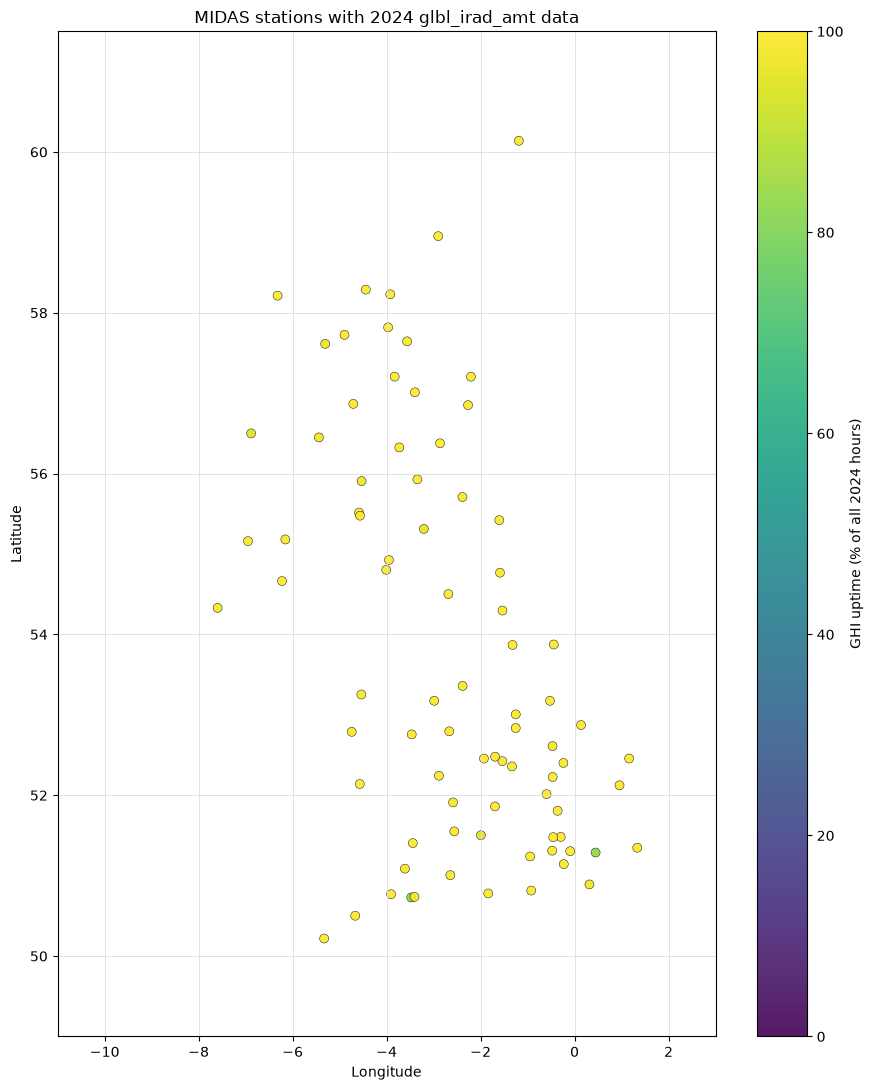

Saved station uptime map to: ..\data\outputs\MIDAS202607\station_2024_ghi_uptime_map.png


,station_id,station_name_from_path,source_file,observed_hours,valid_ghi_hours,calendar_coverage_pct,ghi_uptime_pct,ghi_valid_when_observed_pct
6,56424,winterbourne-no2,west-midlands\56424_winterbourne-no2\qc-versio...,8784,8784,100.000000,100.000000,100.0
7,24102,coventry-coundon,west-midlands\24102_coventry-coundon\qc-versio...,8784,8784,100.000000,100.000000,100.0
15,19206,st-athan,south-glamorgan\19206_st-athan\qc-version-1\mi...,8784,8784,100.000000,100.000000,100.0
13,00719,wisley,surrey\00719_wisley\qc-version-1\midas-open_uk...,8784,8784,100.000000,100.000000,100.0
14,00440,wattisham,suffolk\00440_wattisham\qc-version-1\midas-ope...,8784,8784,100.000000,100.000000,100.0
...,...,...,...,...,...,...,...,...
58,01023,eskdalemuir,dumfriesshire\01023_eskdalemuir\qc-version-1\m...,8457,8457,96.277322,96.277322,100.0
76,18974,tiree,argyll-in-strathclyde-region\18974_tiree\qc-ve...,8360,8360,95.173042,95.173042,100.0
2,00886,lyneham,wiltshire\00886_lyneham\qc-version-1\midas-ope...,8338,8338,94.922587,94.922587,100.0
60,62208,exeter-surfacenet-enclosure-aws,devon\62208_exeter-surfacenet-enclosure-aws\qc...,7288,7288,82.969035,82.969035,100.0


In [8]:
import matplotlib.pyplot as plt

# Join the availability summary to station coordinates and map stations with valid GHI.
metadata_path = data_root / "station-metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError(
        f"Station metadata not found at {metadata_path}. Run the metadata download cell first."
    )

with metadata_path.open("r", encoding="utf-8-sig", errors="replace") as file:
    metadata_lines = file.readlines()
metadata_header = next(
    index
    for index, line in enumerate(metadata_lines)
    if line.startswith("src_id,") and "station_latitude" in line
)
station_metadata = pd.read_csv(
    metadata_path,
    skiprows=metadata_header,
    engine="python",
)

latitude_column = "station_latitude"
longitude_column = "station_longitude"
metadata_id_column = "src_id"

station_metadata["station_id"] = (
    station_metadata[metadata_id_column].astype(str).str.extract(r"(\d+)")[0]
)
stations_for_map = station_availability.merge(
    station_metadata[
        ["station_id", latitude_column, longitude_column]
    ].drop_duplicates("station_id"),
    on="station_id",
    how="left",
)

midas_output_dir = Path("../data/outputs/MIDAS202607")
midas_output_dir.mkdir(parents=True, exist_ok=True)
station_availability_path = midas_output_dir / "station_2024_ghi_availability.csv"
stations_for_map.to_csv(station_availability_path, index=False)
print(f"Saved station availability summary to: {station_availability_path}")
print(
    f"Stations with coordinates: "
    f"{stations_for_map[latitude_column].notna().sum()}/{len(stations_for_map)}"
)

mapped_stations = stations_for_map.dropna(
    subset=[latitude_column, longitude_column, "ghi_uptime_pct"]
)
fig, ax = plt.subplots(figsize=(9, 11))
scatter = ax.scatter(
    mapped_stations[longitude_column],
    mapped_stations[latitude_column],
    c=mapped_stations["ghi_uptime_pct"],
    cmap="viridis",
    vmin=0,
    vmax=100,
    s=42,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.9,
)
fig.colorbar(scatter, ax=ax, label="GHI uptime (% of all 2024 hours)")
ax.set_title(f"MIDAS stations with 2024 {GHI_FIELD} data")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-11, 3)
ax.set_ylim(49, 61.5)
ax.grid(color="#dddddd", linewidth=0.6)
fig.tight_layout()
map_path = midas_output_dir / "station_2024_ghi_uptime_map.png"
fig.savefig(map_path, dpi=200)
plt.show()
print(f"Saved station uptime map to: {map_path}")

station_availability.sort_values("ghi_uptime_pct", ascending=False)

## Compare MIDAS stations with the existing GHI instrument locations

The two datasets are matched by nearest latitude/longitude rather than station name. Small differences are expected because the reference coordinates are rounded to two decimal places.

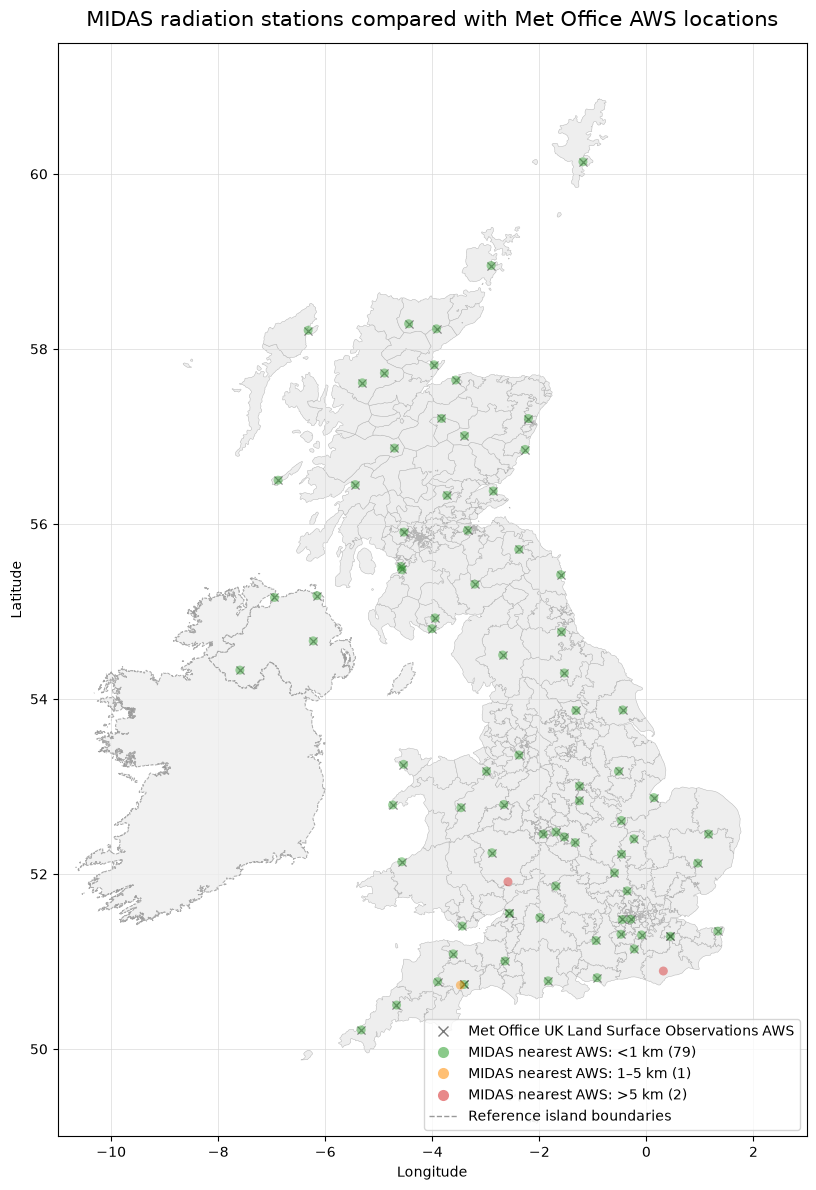

Saved comparison map to: ..\data\outputs\MIDAS202607\midas_vs_aws_locations_distance_bands.png


In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pathlib import Path


# ---------------------------------------------------------------------
# Load the map layers exported by 02_GSP_regions.ipynb
# ---------------------------------------------------------------------

reference_data_path = Path("../data/outputs/reference_data")

gsp_regions_path = (
    reference_data_path
    / "gsp_regions_with_colour_and_ghi_coverage.geojson"
)

island_boundaries_path = (
    reference_data_path
    / "reference_boundaries.geojson"
)

gsp_regions_for_map = gpd.read_file(gsp_regions_path)
island_boundaries = gpd.read_file(island_boundaries_path)


# ---------------------------------------------------------------------
# Prepare the matched station locations
# ---------------------------------------------------------------------

# The previous comparison cell creates this table by matching each
# MIDAS station to its nearest AWS reference location.
plot_locations = location_comparison.copy()

# Assign the requested distance categories.
def distance_category(distance_km):
    if distance_km < 1:
        return "<1 km"
    elif distance_km <= 5:
        return "1–5 km"
    else:
        return ">5 km"


plot_locations["distance_category"] = (
    plot_locations["distance_km"]
    .apply(distance_category)
)


# ---------------------------------------------------------------------
# Plot the land, AWS locations, and MIDAS locations
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 12))

# GSP polygons provide the main Great Britain land area.
gsp_regions_for_map.plot(
    ax=ax,
    facecolor="#eeeeee",
    edgecolor="#b5b5b5",
    linewidth=0.35,
    zorder=1,
)

# Add Northern Ireland, Republic of Ireland, and the smaller islands
# using the same boundary layer exported by the GSP notebook.
island_boundaries.plot(
    ax=ax,
    facecolor="#eeeeee",
    edgecolor="#999999",
    linewidth=0.7,
    linestyle="--",
    alpha=0.8,
    zorder=2,
)


# Plot the AWS locations first so the MIDAS points remain visible above them.
ax.scatter(
    plot_locations["reference_longitude"],
    plot_locations["reference_latitude"],
    s=34,
    marker="x",
    color="#333333",
    alpha=0.55,
    linewidths=0.9,
    zorder=4,
)


# Plot MIDAS points using the distance from their nearest AWS location.
distance_colours = {
    "<1 km": "#2ca02c",   # green
    "1–5 km": "#ff8c00",  # orange
    ">5 km": "#d62728",   # red
}

for category, colour in distance_colours.items():
    category_locations = plot_locations[
        plot_locations["distance_category"] == category
    ]

    ax.scatter(
        category_locations["midas_longitude"],
        category_locations["midas_latitude"],
        s=42,
        color=colour,
        alpha=0.45,
        edgecolors="none",
        zorder=5,
    )


# ---------------------------------------------------------------------
# Formatting and legend
# ---------------------------------------------------------------------

ax.set_title(
    "MIDAS radiation stations compared with Met Office AWS locations",
    fontsize=15,
    pad=12,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(-11, 3)
ax.set_ylim(49, 61.5)

ax.grid(
    color="#d9d9d9",
    linewidth=0.6,
    alpha=0.8,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="x",
        color="#333333",
        linestyle="None",
        markersize=7,
        alpha=0.65,
        label="Met Office UK Land Surface Observations AWS",
    ),
]

for category, colour in distance_colours.items():
    number_in_category = (
        plot_locations["distance_category"] == category
    ).sum()

    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=colour,
            markeredgecolor="none",
            markersize=8,
            alpha=0.55,
            label=f"MIDAS nearest AWS: {category} ({number_in_category})",
        )
    )

legend_handles.append(
    Line2D(
        [0],
        [0],
        color="#999999",
        linestyle="--",
        linewidth=1,
        label="Reference island boundaries",
    )
)

ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=True,
)

fig.tight_layout()


# ---------------------------------------------------------------------
# Save and display the figure
# ---------------------------------------------------------------------

comparison_map_path = (
    midas_output_dir
    / "midas_vs_aws_locations_distance_bands.png"
)

comparison_map_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    comparison_map_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved comparison map to: {comparison_map_path}")

Any missed?
For above:
- TODO: add lines between sites for >1km matching
- Add totally unpaired (AWS?) sites

In [11]:
import numpy as np
import pandas as pd


MATCH_THRESHOLD_KM = 1.0


# ---------------------------------------------------------------------
# MIDAS stations without a sub-1 km AWS match
# ---------------------------------------------------------------------

midas_without_sub_km_match = (
    location_comparison[
        location_comparison["distance_km"] >= MATCH_THRESHOLD_KM
    ]
    .sort_values("distance_km", ascending=False)
    .copy()
)

print(
    "MIDAS stations without a sub-1 km AWS match:",
    len(midas_without_sub_km_match),
)

display(
    midas_without_sub_km_match[
        [
            "station_id",
            "midas_name",
            "midas_latitude",
            "midas_longitude",
            "reference_name",
            "reference_latitude",
            "reference_longitude",
            "distance_km",
        ]
    ]
)


# ---------------------------------------------------------------------
# AWS stations without a sub-1 km MIDAS match
# ---------------------------------------------------------------------

midas_coordinates = midas_locations[
    ["midas_latitude", "midas_longitude"]
].to_numpy()

aws_coordinates = reference_locations[
    ["latitude", "longitude"]
].to_numpy()

coordinate_differences = (
    aws_coordinates[:, None, :]
    - midas_coordinates[None, :, :]
)

latitude_scale_km = 111.32

longitude_scale_km = (
    111.32
    * np.cos(np.radians(aws_coordinates[:, 0]))[:, None]
)

reverse_distance_km = np.sqrt(
    (
        coordinate_differences[:, :, 0]
        * latitude_scale_km
    ) ** 2
    + (
        coordinate_differences[:, :, 1]
        * longitude_scale_km
    ) ** 2
)

nearest_midas_index = reverse_distance_km.argmin(axis=1)
nearest_midas_distance_km = reverse_distance_km[
    np.arange(len(reference_locations)),
    nearest_midas_index,
]

aws_without_sub_km_match = reference_locations.copy()

aws_without_sub_km_match["nearest_midas_name"] = (
    midas_locations.iloc[nearest_midas_index]
    .reset_index(drop=True)["midas_name"]
)

aws_without_sub_km_match["nearest_midas_distance_km"] = (
    nearest_midas_distance_km
)

aws_without_sub_km_match = (
    aws_without_sub_km_match[
        aws_without_sub_km_match["nearest_midas_distance_km"]
        >= MATCH_THRESHOLD_KM
    ]
    .sort_values(
        "nearest_midas_distance_km",
        ascending=False,
    )
)

print(
    "AWS stations without a sub-1 km MIDAS match:",
    len(aws_without_sub_km_match),
)

display(aws_without_sub_km_match)


# ---------------------------------------------------------------------
# Save both summaries
# ---------------------------------------------------------------------

midas_unmatched_path = (
    midas_output_dir
    / "midas_sites_without_sub_1km_aws_match.csv"
)

aws_unmatched_path = (
    midas_output_dir
    / "aws_sites_without_sub_1km_midas_match.csv"
)

midas_without_sub_km_match.to_csv(
    midas_unmatched_path,
    index=False,
)

aws_without_sub_km_match.to_csv(
    aws_unmatched_path,
    index=False,
)

print(f"Saved: {midas_unmatched_path}")
print(f"Saved: {aws_unmatched_path}")

MIDAS stations without a sub-1 km AWS match: 3


,station_id,midas_name,midas_latitude,midas_longitude,reference_name,reference_latitude,reference_longitude,distance_km
55,00811,herstmonceux-west-end,50.891,0.317,East Malling Automatic Weather Station,51.29,0.45,45.387930
44,00671,ross-on-wye,51.911,-2.586,Almondsbury Automatic Weather Station,51.55,-2.56,40.226164
60,62208,exeter-surfacenet-enclosure-aws,50.729,-3.475,Exeter Airport No 2 Automatic Weather Station,50.74,-3.41,4.741047


AWS stations without a sub-1 km MIDAS match: 7


,name,latitude,longitude,nearest_midas_name,nearest_midas_distance_km
37,Jersey Airport Automatic Weather Station,49.21,-2.19,hurn,176.548189
60,Ronaldsway Automatic Weather Station,54.09,-4.63,dundrennan,89.157275
61,Rosehearty Automatic Weather Station,57.70,-2.12,dyce,55.334884
19,Cliff Farm Automatic Weather Station,56.76,-5.82,dunstaffnage,41.575778
1,Abergwyngregyn Automatic Weather Station,53.24,-4.01,valley,35.072547
33,Hillsborough Automatic Weather Station,54.45,-6.07,aldergrove,25.848648
6,Ardtornish Automatic Weather Station,56.53,-5.77,dunstaffnage,22.130633


Saved: ..\data\outputs\MIDAS202607\midas_sites_without_sub_1km_aws_match.csv
Saved: ..\data\outputs\MIDAS202607\aws_sites_without_sub_1km_midas_match.csv
